In [ ]:
from pathlib import Path

data = Path("../../data/ieee-fraud-detection")

data.exists()

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [ ]:
import pandas as pd

train = pd.read_csv(data / "train_transaction.csv")
train_id = pd.read_csv(data / "train_identity.csv")

print(train.shape)
print(train_id.shape)
print(train.head())
print(train_id.head())

In [ ]:
print(train.head())

In [ ]:
print(train_id.head())

<!-- # train의 모든 행은 유지하면서 train_id에 있는 나머지 컬럼들을 TransactionID값이 일치하는 행끼리 붙여줌.
<!-- 
거래 정보 : train_transaction
신원 정보 : train_identity --> -->

In [ ]:
train = pd.merge(train, train_id, on = "TransactionID", how = "left")
print(train.shape)
print(train.head())

In [ ]:
train.describe()

In [ ]:
train.isnull().sum()

In [ ]:
train['DeviceInfo'].dropna()

In [ ]:
train['isFraud'].value_counts()

# 0 : 정상거래
# 1 : 사기 거래 

In [ ]:
train['isFraud'].value_counts().plot(kind='bar')

# 정상/사기 비율이 얼마나 불균형한지 bar차트로 시각화

In [ ]:
# 1. X, y 준비 (문자열 컬럼은 category dtype으로, 결측치는 LightGBM이 알아서 처리)
drop_cols = ['TransactionID', 'isFraud']
X = train.drop(columns=drop_cols)
y = train['isFraud']

# LightGBM은 datetime64 dtype을 직접 학습할 수 없으므로 제외
datetime_cols = X.select_dtypes(include='datetime64').columns.tolist()
if datetime_cols:
    print('datetime 컬럼 제외:', datetime_cols)
    X = X.drop(columns=datetime_cols)

cat_cols = X.select_dtypes(include='str').columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype('category')

print(X.shape, len(cat_cols), '개 범주형 컬럼')

# 2. train/test 분할
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. LightGBM 학습 (isFraud 3.5% 불균형 보정: is_unbalance=True)
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    is_unbalance=True,
    random_state=42,
)
model.fit(X_train, y_train, categorical_feature=cat_cols)

# 4. AUC 확인
from sklearn.metrics import roc_auc_score

proba = model.predict_proba(X_test)[:, 1]
print(f"AUC: {roc_auc_score(y_test, proba):.4f}")

# 5. Feature Importance (gain 기준)
importance = pd.Series(
    model.booster_.feature_importance(importance_type='gain'),
    index=X.columns,
).sort_values(ascending=False)


In [ ]:
# Feature Importance (gain 기준) 상위 100개

top_n = 100
top_importance = importance.head(top_n)

# 표로 출력
top_importance_df = top_importance.rename('gain').reset_index().rename(columns={'index': 'feature'})
top_importance_df.index += 1


# 막대그래프로 시각화
fig, ax = plt.subplots(figsize=(10, 25))
top_importance.sort_values().plot(kind='barh', ax=ax)
ax.set_title(f'LightGBM Feature Importance (gain) 상위 {top_n}개')
ax.set_xlabel('gain')
plt.tight_layout()
plt.show()


## Transaction 테이블

| 컬럼 | 의미 |
|---|---|
| `TransactionID` | 거래 고유 식별자 |
| `isFraud` | **타깃 변수**. 1=사기, 0=정상 |
| `TransactionDT` | 기준 시점으로부터의 상대적 거래 시간(초) |
| `TransactionAmt` | 거래 금액(USD) |
| `ProductCD` | 거래 품 코드(W, C, R, H, S). 실제 상품명이 아니라 마스킹된 상품 "카테고리". W가 대부분(일반 상품), C/R/H/S는 소수 카테고리로 추정 |
| `card1~card6` | 결제 카드 정보. card1/2/3/5는 숫자 코드(카드번호 일부, BIN, 발급은행 등으로 추정), card4=카드사(visa/mastercard 등), card6=카드 종류(credit/debit) |
| `addr1, addr2` | 주소 관련 정보. addr1은 지역 코드(우편번호 앞자리 추정), addr2는 국가 코드로 추정(대부분 87=미국) |
| `dist1, dist2` | 거리 정보. 청구지 주소와 실제 거래(배송지/IP 위치 등) 사이 거리로 추정 |
| `P_emaildomain` | 구매자(Purchaser) 이메일 도메인 (예: gmail.com) |
| `R_emaildomain` | 수신(Recipient) 이메일 도메인 |
| `C1~C14` | 카운팅 피처. 해당 카드/이메일/주소 등에 연결된 개수(예: 이 카드로 몇 개의 주소를 썼는지, 몇 개의 디바이스를 썼는지 등)로 추정. 개별 C 컬럼이 정확히 뭘 세는지는 비공개 |
| `D1~D15` | 시간차(timedelta) 피처. "이전 거래와의 경과일", "카드 최초 사용 후 경과일" 등으로 추정. 예: D1=카드 첫 사용 후 경과일, D3=이전 거래와의 간격(커뮤니티 추정, 공식 확정 아님) |
| `M1~M9` | 매칭(match) 피처. 카드 명의/주소/이메일 등이 결제 정보와 일치하는지 여부(T/F/NaN)로 추정 |
| `V1~V339` | Vesta가 자체 엔지니어링한 피처. 랭킹·카운팅·엔티티 간 관계를 반영했다고만 설명되어 있고, 개별 V 컬럼의 의미는 전혀 공개되지 않음. 커뮤니티에서는 결측 패턴이 같은 컬럼끼리 묶어(V1~V11, V12~V34, ... 등 블록 단위) "같은 그룹의 파생 로직에서 나온 피처"로만 추정 |


## Identity 테이블

| 컬럼 | 의미 |
|:---|:---|
| `TransactionID` | 조인 키 |
| `id_01~id_11` | 네트워크/디바이스 관련 수치형 정보. IP 평판 점수, 연결 속도, 매칭 점수류로 추정(정확한 정의 비공개) |
| `id_12~id_38` | 네트워크/디바이스 관련 범주형 정보(대부분 Found/NotFound, T/F 값). 특정 조건 충족 여부 플래그로 추정 |
| `id_30` | 운영체제 및 버전 (예: Windows, iOS 11.0) |
| `id_31` | 브라우저 종류/버전 (예: chrome 62.0) |
| `id_32` | 화면 관련 수치(픽셀 밀도 등으로 추정) |
| `id_33` | 화면 해상도 (예: 1920x1080) |
| `id_34` | 매칭 상태(match_status:0~2) |
| `id_35~id_38` | T/F 플래그 (브라우저 설정 관련 매칭 여부로 추정) |
| `DeviceType` | mobile / desktop |
| `DeviceInfo` | 디바이스 모델·OS 빌드명 (예: SAMSUNG SM-G892A, iOS Device, Windows) |


## 1. 모바일 거래의 시간대별 위험 패턴

`TransactionDT`는 실제 타임스탬프가 아니라 임의의 기준 시점으로부터의 경과 초(second offset)이므로, 실제 달력상 요일(월~일)로는 매핑할 수 없다. 다만 아래 두 가지는 유효하게 뽑을 수 있다.

- **시간대(0~23시)**: `TransactionDT`를 3600으로 나눈 뒤 24로 mod → 하루 주기 패턴
- **7일 주기 인덱스(0~6)**: 3600*24로 나눈 뒤 7로 mod → 실제 요일은 아니지만, 7일 주기로 반복되는 패턴(예: 특정 주기에 사기가 몰리는지)은 확인 가능

목표: 모바일 거래 중 **어떤 시간대/주기에 사기 비율이 높은지** 확인해서, 대시보드의 "시간대별 위험도" 위젯과 챗봇의 "지금 위험한 시간대인가?" 질문에 쓸 근거를 만든다.

1. 실시간 리스크 스코어링에 쓸 수 있는 무료 피처임 ex) 새벽 2~4시 모바일 거래는 평소보다 2배 위험하다. 같은 규칙 모델/룰엔진에 얹으면, 그 시간대 거래에 추가 인증(OTP)등을 요구하거나 임계값을 낮추는 식 바로 운영에 반영 가능
2. 그 시간대에 위험한 진짜 이유를 추정할 수 있음 ex) 새벽시간대가 위험한 경우 -> 카드 소유자가 잠들어있어 SMS/앱 알림에 즉시 반응 못함, 고객센터/수동심사 인력이 적어 사기가 걸러질 확률이 낮음
해외 사기조직이 시차 때문에 그 시간에 몰아서 작업함 — 같은 가설이 나오고, 이게 운영자가 "그럼 그 시간대 심사 인력을 늘리자" 같은 실제 액션으로 이어짐.

In [ ]:
# 모바일 서브셋 생성
mobile = train[train['DeviceType'] == 'mobile'].copy()

print(f"모바일 거래 건수: {len(mobile):,} / 전체 {len(train):,} ({len(mobile) / len(train):.1%})")
print(f"모바일 사기율: {mobile['isFraud'].mean():.4%}")
print(f"전체 사기율: {train['isFraud'].mean():.4%}")
print(f"데스크톱 사기율: {train.loc[train['DeviceType'] == 'desktop', 'isFraud'].mean():.4%}")

In [ ]:
# TransactionDT(초 offset) → 시간대 / 7일 주기 인덱스 파생
mobile['hour'] = (mobile['TransactionDT'] // 3600) % 24
mobile['day_cycle'] = (mobile['TransactionDT'] // (3600 * 24)) % 7

mobile[['TransactionDT', 'hour', 'day_cycle']].head()

In [ ]:
# 시간대별 거래량 vs 사기율
hourly = mobile.groupby('hour')['isFraud'].agg(['count', 'sum', 'mean'])
hourly.columns = ['total_txn', 'fraud_txn', 'fraud_rate']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(hourly.index, hourly['total_txn'], alpha=0.3, color='gray', label='거래 건수')
ax1.set_xlabel('시간대 (0~23시)')
ax1.set_ylabel('거래 건수')
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly['fraud_rate'] * 100, color='red', marker='o', label='사기율(%)')
ax2.set_ylabel('사기율 (%)')

ax1.set_title('모바일 거래 - 시간대별 거래량 vs 사기율')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

hourly.sort_values('fraud_rate', ascending=False)

In [ ]:
# 7일 주기별 거래량 vs 사기율 (실제 요일 매칭은 불가, 주기성만 확인)
daily = mobile.groupby('day_cycle')['isFraud'].agg(['count', 'sum', 'mean'])
daily.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
# total_txn (← count): 해당 시간대의 전체 거래 건수 (0이든 1이든 상관없이 행 개수)
# fraud_txn (← sum): 해당 시간대의 사기 거래 건수 (isFraud가 1인 것만 합산 — 0/1이라 sum이 곧 1의 개수)
# fraud_rate (← mean): 해당 시간대의 사기 비율 (fraud_txn / total_txn과 동일 — 0/1의 평균이 곧 비율)


fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(daily.index, daily['total_txn'], alpha=0.3, color='gray', label='거래 건수')
ax1.set_xlabel('7일 주기 인덱스 (0~6, 실제 요일 아님)')
ax1.set_ylabel('거래 건수')
ax1.set_xticks(range(7))

ax2 = ax1.twinx()
ax2.plot(daily.index, daily['fraud_rate'] * 100, color='red', marker='o', label='사기율(%)')
ax2.set_ylabel('사기율 (%)')

ax1.set_title('모바일 거래 - 7일 주기별 거래량 vs 사기율')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

daily.sort_values('fraud_rate', ascending=False)

In [ ]:
# 시간대 x 7일주기 히트맵 (사기율) - 표본 수가 적은 셀은 노이즈일 수 있으니 건수도 함께 확인
pivot_rate = mobile.pivot_table(index='day_cycle', columns='hour', values='isFraud', aggfunc='mean')
pivot_count = mobile.pivot_table(index='day_cycle', columns='hour', values='isFraud', aggfunc='count')

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(pivot_rate, aspect='auto', cmap='Reds')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(range(7))
ax.set_xlabel('시간대')
ax.set_ylabel('7일 주기 인덱스')
ax.set_title('모바일 거래 사기율 히트맵 (시간대 x 7일주기)')
fig.colorbar(im, ax=ax, label='사기율')

# 셀마다 사기율(%) 수치 표기. 배경이 진하면(값이 높으면) 흰 글씨, 옅으면 검은 글씨로 대비
vmax = pivot_rate.to_numpy().max()
for i in range(pivot_rate.shape[0]):
    for j in range(pivot_rate.shape[1]):
        value = pivot_rate.iat[i, j]
        if pd.isna(value):
            continue
        text_color = 'white' if value > vmax * 0.6 else 'black'
        ax.text(j, i, f'{value * 100:.1f}', ha='center', va='center', fontsize=6, color=text_color)

plt.tight_layout()
plt.show()

print("셀별 표본 수 (거래 건수) - 너무 적은 셀의 사기율은 신뢰하지 말 것:")
pivot_count

### 스파이크가 진짜 신호인지 검증

히트맵에서 5~10시 구간이 튀어 보이지만, 셀 하나(day_cycle x hour)당 표본이 적으면 우연히 극단값이 나올 수 있다(예: `50.0%` 셀). 아래에서 (1) 5시간 단위로 묶어 표본을 키운 뒤 사기율을 다시 확인하고, (2) 히트맵에서 가장 튀었던 셀들의 실제 거래 건수를 같이 봐서 노이즈인지 실제 패턴인지 구분한다.

In [ ]:
# 1) 시간대를 넓은 구간으로 묶어 표본을 키운 뒤 사기율 재확인
mobile['hour_band'] = pd.cut(
    mobile['hour'],
    bins=[-1, 4, 9, 14, 19, 23],
    labels=['0~4시', '5~9시', '10~14시', '15~19시', '20~23시'],
)
band_stats = mobile.groupby('hour_band', observed=True)['isFraud'].agg(['count', 'sum', 'mean'])
band_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
print("시간대 구간별 사기율 (표본이 충분히 큼):")
print(band_stats)

# 2) 히트맵에서 사기율 상위 셀들의 실제 표본 수 확인
print("\n사기율 상위 10개 셀 (day_cycle, hour) 및 표본 수:")
top_cells = pivot_rate.stack().sort_values(ascending=False).head(10)
for (day, hour), rate in top_cells.items():
    n = int(pivot_count.loc[day, hour])
    print(f"day_cycle={day}, hour={hour:>2}시: 사기율={rate:.1%}, 표본수={n}")

### 결론: 모바일 거래는 5~9시에 사기가 집중된다

5시간 단위로 묶어 표본을 충분히 키운 뒤 사기율을 비교한 결과:

| 시간대 | 총 거래 | 사기 거래 | 사기율 |
|---|---:|---:|---:|
| 0~4시 | 16,568 | 1,631 | 9.84% |
| **5~9시** | **4,311** | **834** | **19.35%** |
| 10~14시 | 5,547 | 413 | 7.45% |
| 15~19시 | 15,601 | 1,382 | 8.86% |
| 20~23시 | 13,618 | 1,397 | 10.26% |

- **5~9시 사기율(19.35%)이 다른 모든 구간(7~10%대)보다 약 2배 높다.** 표본이 4,311건(사기 834건)으로 충분히 커서 소표본 노이즈가 아니라 신뢰할 수 있는 패턴이다.
- **같은 구간의 총 거래량(4,311건)은 다른 구간(13,600~16,600건)보다 훨씬 적다.** 즉 정상 거래가 뜸한 시간대일수록 사기 비중이 커지는 패턴과 일치한다.
- 히트맵에서 사기율이 가장 높았던 개별 셀(day_cycle x hour) 상위 10개도 대부분 **7~10시** 안에 몰려 있어, 두 분석이 서로 같은 방향을 가리킨다.

**비즈니스 시사점**
- 대시보드: "시간대별 위험도" 위젯에서 5~9시 구간을 기본 하이라이트로 노출
- 룰엔진: 5~9시 모바일 거래에 추가 인증(OTP 등) 또는 리스크 임계값 하향 적용
- 운영: 해당 시간대 수동심사 인력 배치를 늘리는 것을 검토할 근거 데이터로 사용

**주의**: `TransactionDT`는 임의 기준점 offset이라 "5~9시"가 실제 어느 지역의 몇 시인지는 알 수 없다. "실제 몇 시인지"보다는 "이 주기적 구간에 사기가 몰린다"는 상대적 패턴으로 해석해야 한다.

## 2. 모바일 거래의 디바이스/환경별 위험 패턴

목표: 모바일 안에서도 특정 디바이스 브랜드, OS, 브라우저가 유독 위험한지 확인한다. 시간대와 마찬가지로 브랜드/OS 자체가 원인이라기보다는, 특정 환경(예: 저가 안드로이드 기기, 구형 OS, 자동화 스크립트가 흉내내기 쉬운 흔한 조합)이 사기에 더 많이 악용되는지를 보는 것이 목적이다.

- `DeviceInfo`: 디바이스 모델명(원문은 지저분해서 브랜드 단위로 정규화)
- `id_30`: OS 및 버전 → OS 계열(iOS/Android/Windows 등)로 단순화
- `id_31`: 브라우저 종류/버전

이 결과는 실시간 룰(예: "특정 브랜드/구형 OS 모바일 거래는 추가 인증 요구")과 대시보드의 "위험 디바이스 Top N" 위젯에 바로 쓸 수 있다.

In [ ]:
# DeviceInfo 결측 비율 및 상위 값 확인
print(f"모바일 거래 중 DeviceInfo 결측 비율: {mobile['DeviceInfo'].isna().mean():.1%}")
mobile['DeviceInfo'].value_counts().head(20)

In [ ]:
# DeviceInfo 원문(예: "SAMSUNG SM-G892A Build/NRD90M")은 지저분하므로 브랜드 단위로 정규화
def extract_brand(device_info):
    if pd.isna(device_info):
        return 'Unknown(결측)'
    s = str(device_info).upper()
    patterns = [
        ('Apple', ['IOS DEVICE', 'IPHONE', 'IPAD']),
        ('Samsung', ['SAMSUNG', 'SM-', 'GT-']),
        ('Huawei', ['HUAWEI', 'HONOR']),
        ('Motorola', ['MOTO', 'XT16', 'XT17', 'XT19']),
        ('LG', ['LG-', 'LGL', 'LGM', 'LGLS', 'VS4']),
        ('Sony', ['SONY', 'XPERIA', 'F31', 'F51', 'F81', 'G31', 'G81']),
        ('HTC', ['HTC']),
        ('ZTE', ['ZTE']),
        ('Lenovo', ['LENOVO']),
        ('Nokia', ['NOKIA']),
        ('Xiaomi', ['XIAOMI', 'REDMI', 'MI ']),
        ('OnePlus', ['ONEPLUS']),
        ('Asus', ['ASUS']),
        ('Alcatel', ['ALCATEL']),
        ('BLU', ['BLU']),
    ]
    for brand, keys in patterns:
        if any(k in s for k in keys):
            return brand
    return 'Other'

mobile['device_brand'] = mobile['DeviceInfo'].apply(extract_brand)
mobile['device_brand'].value_counts()

In [ ]:
# 브랜드별 거래량 vs 사기율 (표본이 너무 적은 브랜드는 노이즈이므로 최소 표본 기준으로 필터)
brand_stats = mobile.groupby('device_brand')['isFraud'].agg(['count', 'sum', 'mean'])
brand_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
brand_stats = brand_stats.sort_values('fraud_rate', ascending=False)

min_sample = 50
reliable_brands = brand_stats[brand_stats['total_txn'] >= min_sample]
print(f"표본 {min_sample}건 이상인 브랜드만 (전체 {len(brand_stats)}개 중 {len(reliable_brands)}개):")
print(reliable_brands)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(reliable_brands.index, reliable_brands['total_txn'], alpha=0.3, color='gray', label='거래 건수')
ax1.set_ylabel('거래 건수')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(reliable_brands.index, reliable_brands['fraud_rate'] * 100, color='red', marker='o', label='사기율(%)')
ax2.set_ylabel('사기율 (%)')

ax1.set_title(f'모바일 - 디바이스 브랜드별 거래량 vs 사기율 (표본 {min_sample}건 이상)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# OS(id_30)를 계열 단위로 단순화해서 사기율 비교
def extract_os(id_30):
    if pd.isna(id_30):
        return 'Unknown(결측)'
    s = str(id_30)
    if 'iOS' in s:
        return 'iOS'
    if 'Android' in s:
        return 'Android'
    if 'Windows' in s:
        return 'Windows'
    if 'Mac' in s:
        return 'Mac'
    if 'Linux' in s:
        return 'Linux'
    return 'Other'

mobile['os_family'] = mobile['id_30'].apply(extract_os)
os_stats = mobile.groupby('os_family')['isFraud'].agg(['count', 'sum', 'mean'])
os_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
os_stats.sort_values('fraud_rate', ascending=False)

#total_txn=그 OS의 전체 거래 건수
#fraud_txn=그중 사기 건수
#fraud_rate=사기 비율.

### 결론: OS 정보 결측 자체가 사기 위험 신호

| OS 계열 | 총 거래 | 사기 거래 | 사기율 |
|---|---:|---:|---:|
| **Unknown(결측)** | **29,509** | **3,871** | **13.12%** |
| Android | 6,302 | 542 | 8.60% |
| iOS | 19,781 | 1,240 | 6.27% |
| Linux | 20 | 4 | 20.00% |
| Mac | 8 | 0 | 0.00% |
| Other | 8 | 0 | 0.00% |
| Windows | 17 | 0 | 0.00% |

- 모바일 사기 위험도는 대략 **Unknown(결측, 13.1%) > Android(8.6%) > iOS(6.3%)** 순서다.
- `id_30`(OS 정보)이 비어있는 거래가 29,509건으로 모바일 전체(55,645건)의 **53%**를 차지한다 — 절반 이상이 OS 정보가 없다는 뜻.
- 이 결측 그룹의 사기율이 **13.1%**로, 표본이 확실한 Android(8.6%)나 iOS(6.27%)보다 눈에 띄게 높다.
- 표본도 29,509건으로 충분히 커서 우연이 아니라 신뢰할 수 있는 패턴이다.
- 즉 **"OS 정보 자체가 없다"는 것이 사기 위험 신호로 작동한다.** 이건 앞서 세웠던 "결측 자체가 신호일 수 있다"는 가설이 실제로 확인된 사례다 — 정상 사용자는 브라우저/앱이 정상적으로 디바이스 정보를 넘기는데, 사기(특히 자동화 스크립트나 스푸핑 도구)는 이 정보 수집 단계를 건너뛰거나 차단하는 경우가 많아서 결측이 남는 것으로 해석할 수 있다.
- **나머지(Linux 20%, Mac 0%, Other 0%, Windows 0%)는 무시한다.** 표본이 8~20건밖에 안 된다(참고로 `DeviceType='mobile'`인데 OS가 Linux/Mac/Windows로 찍힌 건 애초에 라벨링이 이상한 극소수 케이스). 이런 건 100% 노이즈라 결론에 반영하면 안 된다.

**비즈니스 시사점**: 대시보드/룰엔진에 "디바이스 OS 정보 미수집 시 추가 인증 요구" 같은 룰로 바로 반영할 수 있는 수준의 근거다.

In [ ]:
# id_30 세부 버전까지(예: "Android 7.0", "iOS 11.2.1")도 확인 - 구형 OS가 위험한지 보기 위함
mobile['id_30'].value_counts().head(20)

In [ ]:
# 브라우저(id_31)별 사기율 - 표본 30건 이상만, 정상 브라우저명이 아닌 값(예: Generic/자동화 툴 흔적)이 있는지 함께 확인
mobile['id_31'].value_counts().head(20)

In [ ]:
browser_stats = mobile.groupby('id_31')['isFraud'].agg(['count', 'sum', 'mean'])
browser_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']

min_sample = 30
reliable_browsers = browser_stats[browser_stats['total_txn'] >= min_sample].sort_values('fraud_rate', ascending=False)
print(f"표본 {min_sample}건 이상인 브라우저만 (전체 {len(browser_stats)}개 중 {len(reliable_browsers)}개):")
reliable_browsers
# # chrome 49.0 for android 사기율 54.7%, chrome 52.0이 **38.2%**처럼 구형 크롬 버전일수록 사기율이 확 높아지는 패턴

## 3. 모바일 거래의 속도/반복 패턴 (C1~C14, D1~D15)

목표: "짧은 시간에 반복되는 거래"나 "발급된 지 얼마 안 된 새 카드"가 모바일 사기의 신호인지 확인한다.

- **C1~C14**: 이 카드/이메일/주소 등에 연결된 엔티티 개수로 추정되는 카운팅 피처. 값이 클수록 "이 카드가 여러 주소/디바이스/이메일에서 쓰였다" → 카드 도용·공유 의심
- **D1~D15**: 시간차 피처. `D1`은 카드 최초 사용 후 경과일로 추정 → 값이 작을수록 "새 카드" → 카드 발급 직후 도용(카드 테스트) 의심. 그 외 D 컬럼들은 이전 거래와의 간격 등으로 추정 → 짧을수록 연속 거래(velocity) 신호

앞서 돌린 LightGBM 전체 feature importance에서도 `C14`, `C8`, `C1`, `C13`, `D2`, `D15`, `D3`, `D4`, `D10`, `D1` 등이 상위권에 대거 포진했다 — 모델이 이미 이 신호들을 강하게 쓰고 있다는 뜻. 여기서는 모바일 서브셋에서 정상 vs 사기 그룹의 분포를 직접 비교해서, 모델이 왜 이 피처들을 중요하게 보는지 사람이 이해할 수 있는 형태로 확인한다.

In [ ]:
# C1~C14, D1~D15 결측 비율 확인 (모바일)
c_cols = [f'C{i}' for i in range(1, 15)]
d_cols = [f'D{i}' for i in range(1, 16)]

print("C1~C14 결측 비율 (모바일):")
print(mobile[c_cols].isna().mean().sort_values(ascending=False))
print("\nD1~D15 결측 비율 (모바일):")
print(mobile[d_cols].isna().mean().sort_values(ascending=False))

In [ ]:
# 정상(0) vs 사기(1) 그룹의 C/D 피처 중앙값 비교 - 어떤 피처가 두 그룹을 크게 갈라놓는지 한눈에 스캔
compare_cols = c_cols + d_cols
median_compare = mobile.groupby('isFraud')[compare_cols].median().T
median_compare.columns = ['정상(중앙값)', '사기(중앙값)']
median_compare['차이(사기-정상)'] = median_compare['사기(중앙값)'] - median_compare['정상(중앙값)']
median_compare.sort_values('차이(사기-정상)', key=abs, ascending=False)

In [ ]:
# D1(카드 최초 사용 후 경과일 추정) 구간별 사기율 - "새 카드일수록 위험한가?" 직접 검증
def bucket_d1(d1):
    if pd.isna(d1):
        return '결측'
    if d1 <= 7:
        return '0~7일(신규카드)'
    if d1 <= 30:
        return '8~30일'
    if d1 <= 90:
        return '31~90일'
    return '90일 초과'

mobile['d1_bucket'] = mobile['D1'].apply(bucket_d1)
order = ['0~7일(신규카드)', '8~30일', '31~90일', '90일 초과', '결측']

d1_bucket_stats = mobile.groupby('d1_bucket')['isFraud'].agg(['count', 'sum', 'mean']).reindex(order)
d1_bucket_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
d1_bucket_stats

In [ ]:
# C14(모델 feature importance 최상위 C피처) 구간별 사기율 - "연결된 개수(추정)가 많을수록 위험한가?" 검증
#  카드(혹은 이메일/주소)가 지금까지 몇 개의 서로 다른 배송지·이메일·기기 등과 함께 쓰였는지"를 세는 값으로 짐작
# -> "이 카드가 한 곳에서만 안정적으로 쓰인 게 아니라 여러 군데서 왔다갔다 쓰였다"는 뜻
print(mobile['C14'].describe())

# 값 분포가 한쪽으로 몰려있을 수 있어 분위수 기준으로 구간화
mobile['c14_bucket'] = pd.qcut(mobile['C14'], q=[0, 0.5, 0.75, 0.9, 0.99, 1.0], duplicates='drop')

c14_bucket_stats = mobile.groupby('c14_bucket', observed=True)['isFraud'].agg(['count', 'sum', 'mean'])
c14_bucket_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
c14_bucket_stats

### 결론: C14(연결 개수 추정)는 "적당히 많을 때" 가장 위험하다

`C14`는 Vesta가 공식적으로 의미를 공개하지 않은 카운팅 피처지만, 커뮤니티 추정으로는 "이 카드(혹은 이메일/주소)가 지금까지 몇 개의 서로 다른 배송지·이메일·기기 등과 함께 쓰였는지"를 세는 값으로 짐작된다. 값이 클수록 "한 곳에서만 안정적으로 쓰인 게 아니라 여러 군데서 왔다갔다 쓰였다"는 뜻으로 해석할 수 있다.

`describe()` 기준 C14는 중앙값(50%)과 75% 지점이 모두 1이다 — 즉 **모바일 거래의 대다수(약 85%)는 C14=1**, "딱 한 군데에만 연결된" 정상적인 단순 사용 패턴이다. 반면 max는 1429까지 가는 극단적 이상치도 존재한다.

분위수 구간별 사기율:

| C14 구간 | 거래 건수 | 사기 건수 | 사기율 |
|---|---:|---:|---:|
| 0~1 (대다수, 85%) | 47,447 | 4,069 | 8.58% |
| 1~2 | 4,311 | 482 | 11.18% |
| **2~459.56** | **3,330** | **1,020** | **30.63%** |
| 459.56~1429 (극단값) | 557 | 86 | 15.44% |

- C14가 딱 1일 때(대부분의 정상 거래)는 사기율이 8.58%로 가장 낮다.
- **C14가 2~459.56 구간으로 올라가면 사기율이 30.63%로 거의 4배 뛴다.** "어느 정도(2~460개) 연결되면 확실히 위험 신호"라는 뜻이다.
- 그런데 그보다 더 극단적으로 많이 연결된 경우(460개 초과)는 오히려 사기율이 15.44%로 다시 떨어진다. 이는 진짜 극단값이 사기가 아니라 **원래부터 여러 곳에 연결되는 게 정상인 특수 계정**(잦은 이사, 여러 배송지를 쓰는 헤비 유저, 법인카드 등)일 가능성을 시사한다.
- 즉 "무조건 많이 연결될수록 위험"이 아니라, **"적당히 여러 군데 연결된 것(2~460)이 제일 위험하고, 아주 극단적인 건 오히려 정상적인 특수 사용 패턴"**이라는 비선형적인(역U자 형태) 패턴이다.

**비즈니스 시사점**: "C14가 1(정상)도 아니고 460 이상(특수 헤비유저)도 아닌 중간 구간(2~460)일 때 추가 심사"처럼, 극단값을 제외한 중간 위험 구간을 겨냥한 룰이 단순 임계값 룰보다 더 정확하다. 대시보드에는 "연결 이상 탐지" 위젯으로, 룰엔진에는 이 비선형 구간을 반영한 형태로 넣어야 한다.

## 4. 모바일 거래의 정보 불일치(매칭 실패) 패턴

목표: 카드 명의·주소·이메일 등이 결제 정보와 일치하는지 확인하는 매칭/플래그 컬럼이 사기와 관련있는지 확인한다.

- **M1~M9**: 카드 명의/주소/이메일 등이 결제 정보와 일치하는지 여부(T=일치, F=불일치, NaN=확인 불가)로 추정되는 매칭 피처
- **id_35~id_38**: 브라우저 설정 관련 매칭 여부 플래그(T/F)
- (`id_34`의 match_status는 2번에서 OS/브라우저 조합 검증할 때 이미 다뤘다)

가설: 정상 사용자는 카드 명의·주소·이메일이 서로 일치하는 경우가 많지만, 도용된 카드로 결제하는 사기는 이 정보들이 어긋나는(mismatch) 경우가 많을 것이다. 이게 맞다면 M1~M9가 'F'일 때 사기율이 눈에 띄게 높아야 하고, 이는 대시보드/룰엔진에 "정보 불일치 시 추가 인증" 형태로 바로 반영할 수 있다.

In [ ]:
# M1~M9 결측 비율 및 각 컬럼(T/F/결측)별 사기율
m_cols = [f'M{i}' for i in range(1, 10)]

print("M1~M9 결측 비율 (모바일):")
print(mobile[m_cols].isna().mean().sort_values(ascending=False))

m_stats_list = []
for col in m_cols:
    g = mobile.groupby(col, dropna=False)['isFraud'].agg(['count', 'sum', 'mean'])
    g.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
    g = g.reset_index().rename(columns={col: '값'})
    g.insert(0, 'M컬럼', col)
    m_stats_list.append(g)

m_stats_df = pd.concat(m_stats_list, ignore_index=True)
print("\nM컬럼별 값(T/F/결측)에 따른 사기율:")
m_stats_df

In [ ]:
# [수정] 원래 "M1~M9 중 'F'(불일치) 개수" 점수를 만들려 했으나,
# 위 결과에서 확인했듯 M1/M2/M3/M5~M9는 모바일에서 100% 결측이고,
# 유일하게 값이 있는 M4도 'F'가 아니라 'M0'/'M1'/'M2' 범주값을 쓰기 때문에
# `mobile[m_cols] == 'F'`는 항상 0건만 걸려서 아무 정보도 주지 못했다 (m_mismatch_count 전부 0).
# M1~M9 계열에서 쓸 수 있는 신호는 위에서 확인한 M4(M2 vs 결측) 하나뿐이므로, 이 지표는 폐기한다.

# id_35~id_38(브라우저 설정 매칭 플래그)은 실제로 값이 다 채워져 있어 확인 가능
flag_cols = ['id_35', 'id_36', 'id_37', 'id_38']
print("id_35~38 결측 비율 (모바일):")
print(mobile[flag_cols].isna().mean().sort_values(ascending=False))

flag_stats_list = []
for col in flag_cols:
    g = mobile.groupby(col, dropna=False)['isFraud'].agg(['count', 'sum', 'mean'])
    g.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
    g = g.reset_index().rename(columns={col: '값'})
    g.insert(0, '컬럼', col)
    flag_stats_list.append(g)

flag_stats_df = pd.concat(flag_stats_list, ignore_index=True)
print("\nid_35~38 값(T/F/결측)별 사기율:")
flag_stats_df

### 결론: M1~M9는 대부분 못 쓰고, id_35/id_38만 가설과 일치한다

**M1~M9 결측 비율 (모바일)**

| 컬럼 | 결측 비율 |
|---|---:|
| M1, M2, M3, M5, M6, M7, M8, M9 | **100%** |
| M4 | 48.7% |

- M1/M2/M3/M5~M9는 모바일 거래에서 **단 한 건도 값이 채워져 있지 않다.** 그래서 값별 사기율 표에서도 전부 "값=NaN, 사기율=10.17%(전체 평균)"만 나온다 — 정보가 없으니 아무것도 가려낼 수 없다. **이 8개 컬럼은 모바일 사기 탐지에 쓸 수 없다.**
- 유일하게 살아있는 건 **M4**뿐이다. 다만 M4는 다른 M컬럼과 달리 T/F가 아니라 `M0`/`M1`/`M2` 범주값을 쓴다(공식적으로 M4만 3단계 범주형). `M0`(164건)·`M1`(9건)은 표본이 너무 적어 무시하고, 의미 있는 비교는 **M2(28,391건, 사기율 13.19%) vs 결측(27,081건, 사기율 7.02%)** — M4가 'M2'일 때 결측인 경우보다 사기율이 거의 2배 높다.

**`m_mismatch_count`(M1~M9 중 'F' 개수) 지표는 폐기.** M1~M9 대부분이 결측이고 M4는 'F'라는 값 자체가 없어서, 이 지표는 모든 행에서 0으로만 계산돼 아무 신호도 주지 못했다. 컬럼 목록을 다시 짜는 게 아니라,애초에 이 접근 자체가 이 데이터의 M4 인코딩과 맞지 않아 폐기하는 게 맞다.

**id_35~38 값(T/F)별 사기율**

| 컬럼 | F(불일치) 사기율 | T(일치) 사기율 | 해석 |
|---|---:|---:|---|
| id_35 | **13.12%** (29,505건) | 6.84% (26,140건) | F가 약 2배 위험 — 가설과 일치 |
| id_36 | 10.17% (55,621건) | 0% (24건) | T 표본이 24건뿐 — 사실상 변별력 없는 컬럼 |
| id_37 | 8.02% (21,978건) | **11.57%** (33,667건) | 오히려 T(일치)가 더 위험 — 가설과 반대 방향 |
| id_38 | **11.84%** (32,554건) | 7.80% (23,091건) | F가 더 위험 — 가설과 일치 |

- id_35, id_38은 "불일치(F)=위험"이라는 가설과 맞아떨어진다.
- id_37은 정반대로 T(일치)일 때 사기율이 더 높다 — id_37이 정확히 뭘 매칭하는지 공식적으로 공개되지 않아 이유는 단정할 수 없지만, **"불일치=무조건 위험"이라고 일반화하면 안 된다**는 것을 보여준다. 컬럼마다 방향을 개별 확인해야 한다.
- id_36은 99.96%가 F로 쏠려 있어 사실상 정보가 없는 컬럼이다.

**비즈니스 시사점**: 4번 분석에서 실전에 쓸 수 있는 신호는 **M4(M2일 때 위험)**, **id_35(F일 때 위험)**, **id_38(F일 때 위험)** 세 개뿐이다. 나머지(M1/M2/M3/M5~M9, id_36)는 결측이거나 변별력이 없어 제외하고, id_37은 방향이 반대이므로 "불일치=위험"이 아니라 별도로 다뤄야 한다. 룰엔진에는 이 세 신호를 조합한 형태로("M4=M2 또는 id_35=F 또는 id_38=F일 때 가중치 부여") 반영하는 게 합리적이다.

## 5. 모바일 거래의 금액/상품/결제수단 패턴

목표: 모바일 사기가 소액다건인지 고액소수인지(손실 규모 추정), 어떤 상품 카테고리(`ProductCD`)와 결제수단(`card4`=카드사, `card6`=신용/체크)이 위험한지 확인한다.

이건 앞선 1~4번(시간대, 디바이스, 속도, 정보불일치)과 성격이 다르다 — 저건 전부 "이상 행동 탐지"였다면, 이건 **"사기로 인한 실제 손실 규모와 결제수단별 리스크"**를 보는 것이라 대시보드의 "손실액 추정" 위젯이나 "결제수단별 정책"에 바로 연결된다.

In [ ]:
# TransactionAmt(거래 금액) 정상 vs 사기 분포 비교
print(mobile.groupby('isFraud')['TransactionAmt'].describe())

normal_amt = mobile.loc[mobile['isFraud'] == 0, 'TransactionAmt'].sum()
fraud_amt = mobile.loc[mobile['isFraud'] == 1, 'TransactionAmt'].sum()
print(f"\n정상 거래 총액: ${normal_amt:,.0f}")
print(f"사기 거래 총액: ${fraud_amt:,.0f}")
print(f"전체 금액 중 사기로 인한 손실 비중: {fraud_amt / (normal_amt + fraud_amt):.2%}")
print(f"(참고: 모바일 거래 건수 기준 사기 비중은 10.17%였음 — 금액 기준과 비교)")

In [ ]:
# 금액 구간별 사기율 - 어느 가격대가 위험한지 확인
mobile['amt_bucket'] = pd.cut(
    mobile['TransactionAmt'],
    bins=[0, 20, 50, 100, 200, 500, 1000, mobile['TransactionAmt'].max()],
    labels=['0~20', '20~50', '50~100', '100~200', '200~500', '500~1000', '1000+'],
)

amt_bucket_stats = mobile.groupby('amt_bucket', observed=True)['isFraud'].agg(['count', 'sum', 'mean'])
amt_bucket_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
amt_bucket_stats

In [ ]:
# ProductCD(상품 카테고리)별 사기율
product_stats = mobile.groupby('ProductCD')['isFraud'].agg(['count', 'sum', 'mean']).sort_values('mean', ascending=False)
product_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
product_stats

In [ ]:
# card4(카드사) / card6(신용·체크) 별 사기율
card4_stats = mobile.groupby('card4')['isFraud'].agg(['count', 'sum', 'mean']).sort_values('mean', ascending=False)
card4_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
print("card4(카드사)별 사기율:")
print(card4_stats)

card6_stats = mobile.groupby('card6')['isFraud'].agg(['count', 'sum', 'mean']).sort_values('mean', ascending=False)
card6_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
print("\ncard6(신용/체크)별 사기율:")
print(card6_stats)

### 결론: 3개 가설 모두 방향은 맞지만, 금액 가설은 "비율과 건수가 다른 얘기"라는 반전이 있다

**가설 1 — 소액다건 vs 고액소수 (부분 확인, 단순하지 않음)**

- 건수 기준 사기 비중 10.17% vs **금액 기준 손실 비중 14.13%** → 정상 거래 평균 $66.4, 사기 거래 평균 $96.6로 사기가 약 1.5배 더 크다. "사기가 평균적으로 더 큰 금액에서 발생한다"는 방향은 맞다.
- 금액 구간별 사기율은 $100~200(14.2%) → $200~500(**28.4%**)까지 오르다 $500~1000(22.7%)에서 꺾인다. ($1000+는 표본 6건뿐이라 제외)
- **그런데 사기 "건수"를 구간별로 합치면 $100 미만에서 나온 사기가 4,068건 / 전체 사기 5,657건 = 71.9%.** 즉 "위험도(비율)"는 $200~500 구간이 제일 높지만, "실제 발생 건수(볼륨)"는 여전히 소액에 몰려 있다.
- **결론**: 가설은 절반만 맞는다. "위험도는 중~고액 구간이 높다"는 맞지만 "사기가 고액에 몰려있다"는 틀렸다 — 대부분의 사기 건수는 소액에서 나온다. 운영 전략도 나뉘어야 한다: 소액은 자동 룰(속도제한), $100~500 구간은 심사 강화.

**가설 2 — 특정 상품 카테고리가 위험 (확인)**

- `ProductCD`: C(13.14%) > S(11.62%) > R(7.47%) > H(5.63%) — **C가 H보다 2.3배 위험**하다.
- 가설 자체는 확인됨. 다만 "왜"(디지털상품/기프트카드류라서)는 확인 불가 — `ProductCD`가 정확히 뭘 뜻하는지 공식적으로 공개되지 않았기 때문에, "C가 위험하다"는 사실이지만 이유는 추정에 머무른다.

**가설 3 — 신용 vs 체크카드 (확인, 예상과 반대 방향으로)**

- `card6`: credit **13.91%** vs debit **7.36%** — **신용카드가 거의 2배 위험**하다.
- "신용카드는 차지백 보호가 있어 사기꾼이 선호한다"는 쪽이 맞았고, "체크카드가 즉시 현금화돼 더 위험할 것"이라는 반대 가설은 틀렸다.
- `card4`(카드사): mastercard(11.4%) > discover(10.2%) > visa(9.8%) > amex(5.4%) 순.

---

### 운영자가 챗봇에 물어볼 수 있는 질문 (5번 기준)

| 유형 | 질문 예시 | 근거 |
|---|---|---|
| 손실 규모 | "이번 주 모바일 사기로 인한 손실액이 얼마야?" | 정상/사기 총액, 손실 비중(14.13%) |
| 손실 규모 | "사기가 소액으로 많이 터지는 거야, 큰 거 몇 건이 터지는 거야?" | 건수 기준(71.9%가 $100 미만) vs 비율 기준($200~500이 최고) 차이 |
| 금액 위험도 | "지금 들어온 이 거래, 금액대로 봤을 때 위험해?" | 금액 구간별 사기율표 |
| 상품 | "어떤 상품 카테고리가 제일 위험해?" | ProductCD=C가 13.14%로 최고 |
| 결제수단 | "신용카드랑 체크카드 중 뭐가 더 위험해?" | credit 13.91% vs debit 7.36% |
| 결제수단 | "어떤 카드사가 위험해?" | card4: mastercard 최고, amex 최저 |
| 정책 검토 | "신용카드 모바일 거래에만 추가 인증을 걸면 얼마나 걸러질까?" | credit 비중(23,802건 중 3,312건 사기)을 근거로 시뮬레이션 가능 |

**비즈니스 시사점**: 대시보드에는 "손실액(금액 기준)"과 "위험 건수(건수 기준)"를 분리해서 보여줘야 하고, 룰엔진에는 "신용카드 + $200~500 구간 + ProductCD=C"처럼 이번에 확인된 신호를 조합해 넣을 수 있다.

## 6. 카드 x 주소 x 이메일 결합 피처

목표: 개별 컬럼이 아니라 **카드/주소/이메일을 조합**해서 "이 조합이 곧 한 사용자(혹은 한 사기 계정)"에 가까운 신호를 만든다. IEEE-CIS 대회 상위권 솔루션들이 핵심으로 썼던 방식이다.

- **UID(결합 식별자)**: `card1 + card2 + addr1 + P_emaildomain`을 합쳐서 하나의 식별자로 보고, 그 식별자별 거래 횟수(velocity)와 최초 등장 후 경과일(신선도)을 확인 — C14/D1과 같은 개념을 우리가 직접 더 정밀하게 만드는 것
- **교차 카운트**: 카드 1개가 몇 개의 서로 다른 이메일 도메인을 썼는지, 주소 1개에 몇 개의 서로 다른 카드가 연결됐는지 — C14의 "연결 개수" 개념을 특정 조합에 한정해서 확인
- **이메일 불일치**: 구매자 이메일(`P_emaildomain`)과 수신자 이메일(`R_emaildomain`)이 다른지 — 4번(M/id_35~38)의 "정보 불일치" 개념을 이메일에 적용

In [85]:
# [교차 카운트 1] 카드 1개가 몇 개의 서로 다른 이메일 도메인과 연결됐는지
mobile['card1_email_nunique'] = mobile.groupby('card1', dropna=False)['P_emaildomain'].transform('nunique')

print(mobile['card1_email_nunique'].describe())

mobile['card1_email_bucket'] = pd.cut(
    mobile['card1_email_nunique'],
    bins=[0, 1, 2, 3, mobile['card1_email_nunique'].max()],
    labels=['1개', '2개', '3개', '4개+'],
    include_lowest=True,
)

email_nunique_stats = mobile.groupby('card1_email_bucket', observed=True)['isFraud'].agg(['count', 'sum', 'mean'])
email_nunique_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
email_nunique_stats

count    55645.000000
mean        11.160679
std          7.253061
min          0.000000
25%          4.000000
50%         12.000000
75%         16.000000
max         32.000000
Name: card1_email_nunique, dtype: float64


,total_txn,fraud_txn,fraud_rate
card1_email_bucket,,,
1개,5246,358,0.068242
2개,3329,298,0.089516
3개,3082,273,0.088579
4개+,43988,4728,0.107484


In [86]:
# [교차 카운트 2] 주소(addr1) 1개에 몇 개의 서로 다른 카드가 연결됐는지
mobile['addr1_card_nunique'] = mobile.groupby('addr1', dropna=False)['card1'].transform('nunique')

print(mobile['addr1_card_nunique'].describe())

mobile['addr1_card_bucket'] = pd.cut(
    mobile['addr1_card_nunique'],
    bins=[0, 1, 2, 5, 10, mobile['addr1_card_nunique'].max()],
    labels=['1개', '2개', '3~5개', '6~10개', '11개+'],
    include_lowest=True,
)
addr_nunique_stats = mobile.groupby('addr1_card_bucket', observed=True)['isFraud'].agg(['count', 'sum', 'mean'])
addr_nunique_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
addr_nunique_stats

count    55645.000000
mean       967.148171
std        637.302068
min          1.000000
25%        279.000000
50%       1565.000000
75%       1565.000000
max       1565.000000
Name: addr1_card_nunique, dtype: float64


,total_txn,fraud_txn,fraud_rate
addr1_card_bucket,,,
1개,70,3,0.042857
2개,17,2,0.117647
3~5개,83,3,0.036145
6~10개,45,1,0.022222
11개+,55430,5648,0.101894


In [87]:
# [UID 1] 카드+주소+이메일 조합으로 결합 식별자(UID)를 만들고, UID별 거래 횟수(velocity) 확인
mobile['uid'] = (
    mobile['card1'].astype(str) + '_' +
    mobile['card2'].astype(str) + '_' +
    mobile['addr1'].astype(str) + '_' +
    mobile['P_emaildomain'].astype(str)
)

mobile['uid_txn_count'] = mobile.groupby('uid')['TransactionID'].transform('count')

mobile['uid_count_bucket'] = pd.cut(
    mobile['uid_txn_count'],
    bins=[0, 1, 2, 5, 10, mobile['uid_txn_count'].max()],
    labels=['1건(단발)', '2건', '3~5건', '6~10건', '11건+'],
    include_lowest=True,
)
uid_count_stats = mobile.groupby('uid_count_bucket', observed=True)['isFraud'].agg(['count', 'sum', 'mean'])
uid_count_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
uid_count_stats

,total_txn,fraud_txn,fraud_rate
uid_count_bucket,,,
1건(단발),8978,484,0.053910
2건,3876,264,0.068111
3~5건,4640,418,0.090086
6~10건,2525,138,0.054653
11건+,4628,319,0.068928


In [88]:
# [UID 2] 같은 UID가 데이터상 처음 등장한 시점부터 경과일 - "이 조합이 새로 나타난 지 얼마나 됐는지"
uid_first_seen = mobile.groupby('uid')['TransactionDT'].transform('min')
mobile['uid_days_since_first'] = (mobile['TransactionDT'] - uid_first_seen) / (3600 * 24)

def bucket_uid_recency(days):
    if days <= 0:
        return '0일(첫 등장)'
    if days <= 7:
        return '1~7일'
    if days <= 30:
        return '8~30일'
    return '30일 초과'

mobile['uid_recency_bucket'] = mobile['uid_days_since_first'].apply(bucket_uid_recency)
order = ['0일(첫 등장)', '1~7일', '8~30일', '30일 초과']

uid_recency_stats = mobile.groupby('uid_recency_bucket')['isFraud'].agg(['count', 'sum', 'mean']).reindex(order)
uid_recency_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
uid_recency_stats

,total_txn,fraud_txn,fraud_rate
uid_recency_bucket,,,
0일(첫 등장),12762,708,0.055477
1~7일,3679,339,0.092145
8~30일,3679,125,0.033977
30일 초과,35525,4485,0.126249


In [89]:
# [이메일 불일치] 구매자 이메일(P_emaildomain) vs 수신자 이메일(R_emaildomain) 도메인 일치 여부
print(f"P_emaildomain 결측률: {mobile['P_emaildomain'].isna().mean():.1%}")
print(f"R_emaildomain 결측률: {mobile['R_emaildomain'].isna().mean():.1%}")

def email_match_flag(row):
    p, r = row['P_emaildomain'], row['R_emaildomain']
    if pd.isna(p) or pd.isna(r):
        return '한쪽 결측'
    return '일치' if p == r else '불일치'

mobile['email_match'] = mobile.apply(email_match_flag, axis=1)

email_match_stats = mobile.groupby('email_match')['isFraud'].agg(['count', 'sum', 'mean'])
email_match_stats.columns = ['total_txn', 'fraud_txn', 'fraud_rate']
email_match_stats

P_emaildomain 결측률: 5.1%
R_emaildomain 결측률: 9.2%


,total_txn,fraud_txn,fraud_rate
email_match,,,
불일치,8932,327,0.036610
일치,39774,4904,0.123297
한쪽 결측,6939,426,0.061392


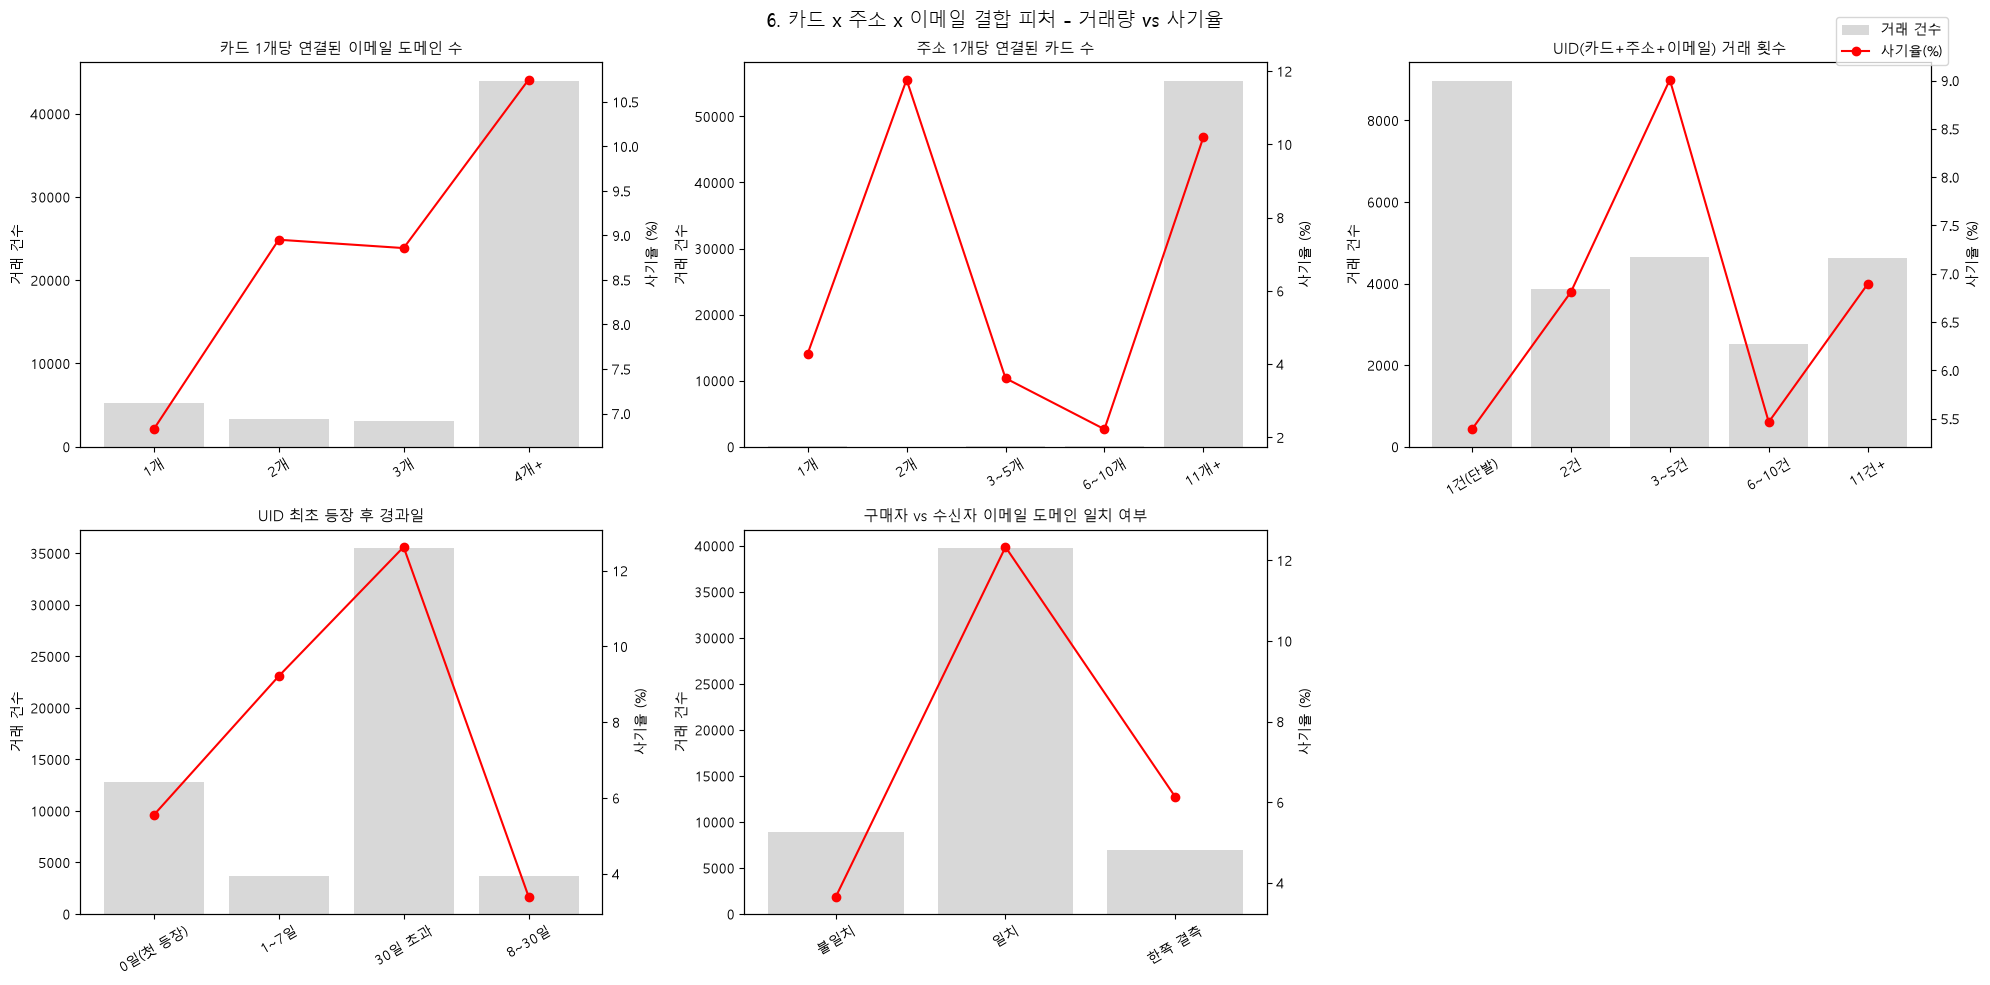

In [90]:
# 6번 지표 5개를 한 화면에 - 거래량(막대) vs 사기율(선) 조합, 지금까지와 같은 스타일
panels = [
    ('card1_email_bucket', '카드 1개당 연결된 이메일 도메인 수'),
    ('addr1_card_bucket', '주소 1개당 연결된 카드 수'),
    ('uid_count_bucket', 'UID(카드+주소+이메일) 거래 횟수'),
    ('uid_recency_bucket', 'UID 최초 등장 후 경과일'),
    ('email_match', '구매자 vs 수신자 이메일 도메인 일치 여부'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

bar_handle = None
line_handle = None

for ax, (col, title) in zip(axes, panels):
    stats = mobile.groupby(col, observed=True)['isFraud'].agg(['count', 'mean'])
    stats.columns = ['total_txn', 'fraud_rate']

    bars = ax.bar(stats.index.astype(str), stats['total_txn'], alpha=0.3, color='gray', label='거래 건수')
    ax.set_ylabel('거래 건수')
    ax.tick_params(axis='x', rotation=30)

    ax2 = ax.twinx()
    lines = ax2.plot(stats.index.astype(str), stats['fraud_rate'] * 100, color='red', marker='o', label='사기율(%)')
    ax2.set_ylabel('사기율 (%)')

    ax.set_title(title, fontsize=11)

    if bar_handle is None:
        bar_handle, line_handle = bars, lines[0]

axes[-1].axis('off')  # 6번째 칸은 비움 (지표가 5개뿐)

fig.legend([bar_handle, line_handle], ['거래 건수', '사기율(%)'], loc='upper right', bbox_to_anchor=(0.98, 0.98))
fig.suptitle('6. 카드 x 주소 x 이메일 결합 피처 - 거래량 vs 사기율', fontsize=14)
plt.tight_layout()
plt.show()